# Notebook 02 — Case Representation
## Sistem CBR Putusan Kasasi Peradilan Anak ABH · Mahkamah Agung RI

Notebook ini menjalankan **Tahap 2 CBR (Case Representation)**:
mengubah teks bersih menjadi struktur data terorganisir yang siap untuk retrieval.

| Komponen | Deskripsi | Output |
|----------|-----------|--------|
| **Metadata** | Nomor perkara, tahun, jenis, pasal, terdakwa, vonis, amar, outcome | `data/case_base.json` |
| **Text Features** | `duduk_perkara`, `memori_kasasi`, `pertimbangan_hukum` | `data/case_base.csv` |
| **Feature Engineering** | `word_count`, `char_count` per dokumen | kolom tambahan di CSV |
| **Visualisasi** | Distribusi outcome & tahun putusan | `data/distribusi_case_base.png` |

**Input:**
- `data/raw/case_*.txt` — teks bersih dari notebook 01
- `data/pdf/*.pdf` — PDF mentah (untuk ekstraksi metadata nomor perkara)
- `logs/cleaning.log` — riwayat pembersihan

**Output:**
- `data/case_base.json` — representasi lengkap (termasuk `teks_lengkap`)
- `data/case_base.csv` — representasi ringkas (tanpa `teks_lengkap`)


## 1 · Import & Konfigurasi

In [1]:
import os
import re
import json
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Resolusi ROOT_DIR ───────────────────────────────────────────────
# Agar path data/ tetap valid baik notebook dijalankan dari root project
# maupun dari dalam folder notebook/ (working directory kernel kadang
# ikut lokasi file .ipynb). Cari ke atas folder yang punya subfolder data/;
# kalau belum ada (run pertama kali), fallback: naik 1 level jika cwd = "notebook".
def _tentukan_root_dir() -> Path:
    cwd = Path.cwd().resolve()
    p = cwd
    for _ in range(4):
        if (p / "data").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    return cwd.parent if cwd.name.lower() in ("notebook", "notebooks") else cwd

ROOT_DIR = _tentukan_root_dir()

RAW_DIR  = ROOT_DIR / 'data' / 'raw'
PDF_DIR  = ROOT_DIR / 'data' / 'pdf'
OUT_DIR      = ROOT_DIR / 'data'
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR    = ROOT_DIR / 'data' / 'eval'
METRICS_DIR = ROOT_DIR / 'data' / 'eval' / 'metrics'
VIZ_DIR     = ROOT_DIR / 'data' / 'eval' / 'visualisasi'
EVAL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = ROOT_DIR / 'logs' / 'cleaning.log'

os.makedirs(ROOT_DIR / 'logs', exist_ok=True)

OUT_DIR.mkdir(parents=True, exist_ok=True)

n_raw = len(list(RAW_DIR.glob('*.txt')))
n_pdf = len(list(PDF_DIR.glob('*.pdf')))

print('Konfigurasi path:')
print(f'  data/raw/   : {n_raw} file txt')
print(f'  data/pdf/   : {n_pdf} file pdf')
print(f'  cleaning.log: {LOG_PATH}')
print()
if n_raw == 0:
    print('[WARN] Tidak ada file .txt di data/raw/ — pastikan notebook 01 sudah dijalankan.')
else:
    print(f'[OK] {n_raw} file teks siap diproses.')

Konfigurasi path:
  data/raw/   : 150 file txt
  data/pdf/   : 150 file pdf
  cleaning.log: D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\logs\cleaning.log

[OK] 150 file teks siap diproses.


## 2 · Pola Regex Ekstraksi Metadata

Pola disesuaikan dengan struktur putusan kasasi MA.
Putusan Anak yang tersensor (nama redacted) tetap dapat diekstrak dari bagian
yang tidak disensor: nomor perkara dari header PDF, amar putusan, pertimbangan hukum.


In [2]:
# ── Nomor perkara kasasi MA — dua varian format ────────────────────
# Format baru : '10004 K/Pid.Sus/2025'  (angka SPASI K/...)
# Format lama : '10/Pid.Sus-Anak/2025'  (angka langsung /)
# Prefix noise: 'gnomor' → 'nomor'
RE_NOMOR = re.compile(
    r'(?:[gG]?[Nn]omor\s+)?'
    r'(\d+\s+K/Pid[\w.\-]*/20\d{2}'
    r'|\d+/Pid[\w.\-]*/20\d{2})',
    re.IGNORECASE
)

RE_TAHUN = re.compile(r'\b(20\d{2})\b')

# ── Vonis: pola diperluas untuk variasi pidana anak ABH ─────────────
RE_PIDANA_V2 = re.compile(
    r'(?:'
    r'p[a-zgi]?k?idana\s+(?:p?enjara|pembinaan\w*|pengawasan)'
    r'(?:\s+kepada\s+\S+(?:\s+\S+){0,3})?'
    r'\s+(?:(?:di|dalam|dalam\s+lembaga\w*)\s+\S+(?:\s+\S+){0,5}\s+)?'
    r'(?:masing-?masing\s+)?selama\s+\d+\s*\([^)]+\)\s*(?:tahun|bulan|hari)'
    r'(?:\s+dan\s+\d+\s*\([^)]+\)\s*(?:tahun|bulan))?'
    r'(?:[^;.\n]{0,100}(?:pelatihan\s+kerja|pembinaan)[^;.\n]{0,80})?'
    r'|p[gi]?idana\s+[Pp]engawasan(?:[^;.\n]{0,30})\d+\s*\([^)]+\)\s*(?:tahun|bulan)'
    r'|(?:lembaga|LPKA)\s+\S+(?:\s+\S+){0,8}\s+selama\s+\d+\s*\([^)]+\)\s*(?:tahun|bulan)'
    r'|[Pp]embinaan\w*\s+(?:di\s+dalam\s+)?[Ll]embaga\w*\s+(?:\S+\s+){0,6}selama\s+\d+\s*\([^)]+\)\s*(?:tahun|bulan)'
    r'|pelatihan\s+kerja[^;.\n]{0,60}selama\s+\d+\s*\([^)]+\)\s*(?:tahun|bulan)'
    r')',
    re.IGNORECASE
)

# ── Pasal: tangkap pasal + ayat + UU ────────────────────────────────
RE_PASAL = re.compile(
    r'[Pp]asal\s+\d+\w*'
    r'(?:\s+[Aa]yat\s*\(?\d+\)?)?'
    r'(?:\s+(?:jo\.?|juncto)\s+[Pp]asal\s+\d+\w*(?:\s+[Aa]yat\s*\(?\d+\)?)?)*'
    r'(?:\s+(?:UU|Undang-Undang|Undang\s+Undang)\s+(?:[Nn]omor|No\.?)\s+\d+\s+[Tt]ahun\s+\d{4}'
    r'(?:\s+[Tt]entang\s+[\w\s]{3,50}?(?=\s*[;,.]|\s+[Pp]asal|\s*$))?)?',
    re.IGNORECASE
)

# ── Amar putusan kasasi ──────────────────────────────────────────────
RE_AMAR = re.compile(
    r'(?:menolak|mengabulkan|memperbaiki|membatalkan|membebaskan|melepaskan)'
    r'[^.]{0,300}(?:kasasi|permohonan|terdakwa)',
    re.IGNORECASE | re.DOTALL
)

# ── Nama terdakwa dari header putusan ────────────────────────────────
RE_TERDAKWA = re.compile(
    r'Nama\s*:\s*\.?\s*([A-Z][A-Z\s.\-]+?)(?:\s+(?:alias|bin|binti|b[Ii]n\w?)\s+[A-Z][A-Z\s.]+)?(?:;|\n|$)',
    re.IGNORECASE
)

# ── Jenis perkara dari nomor ─────────────────────────────────────────
RE_JENIS = re.compile(r'K/([\w.\-]+)/20\d{2}', re.IGNORECASE)

print('Semua pola regex siap:')
print('  RE_NOMOR, RE_TAHUN, RE_PIDANA_V2, RE_PASAL, RE_AMAR, RE_TERDAKWA, RE_JENIS')

Semua pola regex siap:
  RE_NOMOR, RE_TAHUN, RE_PIDANA_V2, RE_PASAL, RE_AMAR, RE_TERDAKWA, RE_JENIS


## 3 · Fungsi Ekstraksi Metadata & Text Features

### 3a · Normalisasi Teks PDF


In [3]:
def normalisasi_pdf(teks):
    """
    Bersihkan artefak watermark/noise pada teks PDF MA.
    Digunakan untuk teks yang dibaca langsung dari PDF (bukan dari data/raw/).

    Artefak yang ditangani:
    - Prefix noise konsonan tunggal sebelum kata kunci ('gnomor' → 'nomor')
    - Watermark 1-2 huruf di akhir baris ('penjara i s' → 'penjara')
    - Baris terpotong di tengah kalimat (gabung dengan baris berikutnya)
    - Kata bertanda hubung yang terputus ('masing-\nmasing' → 'masing-masing')
    - Spasi artefak antara huruf dan angka ('selama3' → 'selama 3')
    """
    teks = re.sub(
        r'\b[bcdfghjklmnpqrstvwxyz](?=nomor|bahwa|membaca|menimbang|mengingat|mengadili|putusan)',
        '', teks, flags=re.IGNORECASE
    )
    teks = re.sub(r'\s+[a-zA-Z]\s+[a-zA-Z]\s*$', '', teks, flags=re.MULTILINE)
    teks = re.sub(r'\s+[a-zA-Z]\s*$', '', teks, flags=re.MULTILINE)
    teks = re.sub(r'(\w-)\n\s*(\w)', r'\1\2', teks)
    teks = re.sub(r'([a-zA-Z,;])\n\s*([a-z])', r'\1 \2', teks)
    teks = re.sub(r'\(\s*([^)]+?)\s*\)', r'(\1)', teks)
    teks = re.sub(r'([a-zA-Z])(\d)', r'\1 \2', teks)
    teks = re.sub(r'(\d)([a-zA-Z])', r'\1 \2', teks)
    teks = re.sub(r'masing-\s+masing', 'masing-masing', teks, flags=re.IGNORECASE)
    teks = re.sub(r'\bp[a-z]?\s+(?=[a-z]?idana|[a-z]?enjara|embinaan)', 'p', teks)
    return teks


def ekstrak_dari_pdf(path_pdf):
    """
    Ekstrak teks dari PDF dengan crop margin yang sama dengan notebook 01.
    Digunakan sebagai fallback untuk ekstraksi nomor perkara dan metadata
    yang memerlukan teks case-sensitive (belum dilowercased).
    """
    try:
        halaman = []
        with pdfplumber.open(path_pdf) as pdf:
            for hal in pdf.pages:
                lebar  = hal.width
                tinggi = hal.height
                area   = hal.within_bbox((
                    max(0, lebar  * 0.15),
                    max(0, tinggi * 0.05),
                    lebar  * 0.85,
                    tinggi * 0.95,
                ), relative=False)
                t = area.extract_text(x_tolerance=3, y_tolerance=3)
                if t:
                    halaman.append(t)
        return normalisasi_pdf('\n'.join(halaman))
    except Exception:
        return ''


print('normalisasi_pdf() dan ekstrak_dari_pdf() siap.')

normalisasi_pdf() dan ekstrak_dari_pdf() siap.


### 3b · Ekstraksi Metadata

In [4]:
def ekstrak_metadata(teks, nama_file='', teks_pdf_mentah=''):
    """
    Ekstrak metadata terstruktur dari teks putusan kasasi MA.

    Parameters
    ----------
    teks            : str — teks bersih dari data/raw/ (lowercase, paragraf utuh)
    nama_file       : str — nama file PDF sumber
    teks_pdf_mentah : str — teks dari PDF langsung (case-sensitive, untuk nomor perkara)

    Returns
    -------
    dict berisi: nomor_perkara, tahun, jenis_perkara, pasal_didakwakan,
                 terdakwa, vonis, amar_putusan, outcome_kasasi, file_sumber
    """
    meta = {}

    # ── Nomor perkara — prioritas dari PDF mentah (case-sensitive) ───
    sumber_nomor = teks_pdf_mentah or teks
    m = RE_NOMOR.search(sumber_nomor)
    meta['nomor_perkara'] = re.sub(r'\s+', '', m.group(1)).upper() if m else ''

    # ── Tahun ─────────────────────────────────────────────────────────
    tahun_list = RE_TAHUN.findall(meta['nomor_perkara'] or teks[:500])
    meta['tahun'] = int(max(tahun_list)) if tahun_list else None

    # ── Jenis perkara ─────────────────────────────────────────────────
    m_jenis = RE_JENIS.search(meta['nomor_perkara'])
    meta['jenis_perkara'] = m_jenis.group(1).strip() if m_jenis else 'Pid.Sus-Anak'

    # ── Pasal ─────────────────────────────────────────────────────────
    sumber_pasal = teks_pdf_mentah or teks
    pasal_list   = RE_PASAL.findall(sumber_pasal)
    pasal_bersih, seen = [], set()
    for p in pasal_list:
        p_strip = re.sub(r'\s+', ' ', p).strip()
        if not re.search(r'\d', p_strip) or len(p_strip) < 7:
            continue
        if len(p_strip) > 120:
            m_cut   = re.search(r'(Tahun\s+\d{4})', p_strip)
            p_strip = p_strip[:m_cut.end()] if m_cut else p_strip[:80]
        p_norm = p_strip.lower()
        if p_norm not in seen:
            pasal_bersih.append(p_strip)
            seen.add(p_norm)
    pasal_lengkap = [p for p in pasal_bersih if 'tahun' in p.lower()]
    pasal_singkat = [p for p in pasal_bersih if 'tahun' not in p.lower()]
    meta['pasal_didakwakan'] = '; '.join((pasal_lengkap[:3] + pasal_singkat[:2])[:5])

    # ── Amar putusan ──────────────────────────────────────────────────
    m_amar = RE_AMAR.search(teks)
    if m_amar:
        meta['amar_putusan'] = re.sub(r'\s+', ' ', m_amar.group(0)).strip()[:300]
    else:
        idx = teks.lower().find('mengadili')
        meta['amar_putusan'] = re.sub(r'\s+', ' ', teks[idx:idx+400]).strip() if idx != -1 else ''

    # ── Terdakwa ──────────────────────────────────────────────────────
    sumber_td = teks_pdf_mentah or teks
    m_td      = RE_TERDAKWA.search(sumber_td)
    if m_td:
        nama_raw    = m_td.group(1).strip()
        nama_bersih = re.sub(r'(?<=[A-Z])[a-z](?=[A-Z])', '', nama_raw)
        nama_bersih = re.sub(r'\s+', ' ', nama_bersih).strip().title()
        meta['terdakwa'] = nama_bersih
    else:
        meta['terdakwa'] = '[TERSENSOR/TIDAK TERDETEKSI]'

    # ── Vonis ─────────────────────────────────────────────────────────
    m_pid = RE_PIDANA_V2.search(teks_pdf_mentah) if teks_pdf_mentah else None
    if not m_pid:
        m_pid = RE_PIDANA_V2.search(normalisasi_pdf(teks))
    meta['vonis'] = re.sub(r'\s+', ' ', m_pid.group(0)).strip() if m_pid else ''

    # ── Outcome kasasi ────────────────────────────────────────────────
    teks_lower = teks.lower()
    if 'menolak permohonan kasasi' in teks_lower:
        meta['outcome_kasasi'] = 'DITOLAK'
    elif 'mengabulkan permohonan kasasi' in teks_lower:
        meta['outcome_kasasi'] = 'DIKABULKAN'
    elif 'memperbaiki' in teks_lower and 'kasasi' in teks_lower:
        meta['outcome_kasasi'] = 'DIPERBAIKI'
    else:
        meta['outcome_kasasi'] = 'TIDAK TERDETEKSI'

    meta['file_sumber'] = nama_file
    return meta


print('ekstrak_metadata() siap.')

ekstrak_metadata() siap.


### 3c · Ekstraksi Text Features (Struktural Putusan Kasasi)

In [5]:
# ── Pola struktural khas putusan kasasi MA ──────────────────────────
RE_DUDUK = re.compile(
    r'(?:duduk\s+perkara|tentang\s+duduk\s+perkara)(.*?)'
    r'(?:pertimbangan\s+hukum|menimbang\s+bahwa|mengadili)',
    re.IGNORECASE | re.DOTALL
)

RE_MEMORI = re.compile(
    r'(?:memori\s+kasasi|alasan[- ]alasan\s+kasasi|keberatan\s+kasasi)(.*?)'
    r'(?:kontra\s+memori|pertimbangan\s+hukum|menimbang\s+bahwa|mengadili)',
    re.IGNORECASE | re.DOTALL
)

RE_PERTIMBANGAN = re.compile(
    r'menimbang\s+bahwa.{100,1000}?(?=menimbang\s+bahwa|mengadili|$)',
    re.IGNORECASE | re.DOTALL
)


def ekstrak_text_features(teks):
    """
    Ekstrak text features struktural dari teks putusan kasasi MA.

    Field yang dihasilkan:
    - duduk_perkara     : kronologi dakwaan s.d. putusan pengadilan bawah
    - memori_kasasi     : argumen pemohon kasasi (paling informatif untuk CBR)
    - pertimbangan_hukum: reasoning hakim MA
    - teks_lengkap      : seluruh teks bersih

    Parameters
    ----------
    teks : str — teks bersih dari data/raw/

    Returns
    -------
    dict dengan keempat field di atas
    """
    feat = {}

    m_duduk = RE_DUDUK.search(teks)
    feat['duduk_perkara'] = (
        re.sub(r'\s+', ' ', m_duduk.group(1)).strip()[:1000]
        if m_duduk else
        re.sub(r'\s+', ' ', teks[:800]).strip()
    )

    m_memori = RE_MEMORI.search(teks)
    if m_memori:
        feat['memori_kasasi'] = re.sub(r'\s+', ' ', m_memori.group(1)).strip()[:1500]
    else:
        idx = teks.lower().find('bahwa')
        feat['memori_kasasi'] = (
            re.sub(r'\s+', ' ', teks[idx:idx+1000]).strip() if idx != -1 else ''
        )

    blok = RE_PERTIMBANGAN.findall(teks)
    feat['pertimbangan_hukum'] = (
        ' ||| '.join(re.sub(r'\s+', ' ', b).strip() for b in blok[:3])
        if blok else feat['duduk_perkara']
    )

    feat['teks_lengkap'] = teks.strip()
    return feat


print('ekstrak_text_features() siap.')
print('  Field: duduk_perkara, memori_kasasi, pertimbangan_hukum, teks_lengkap')

ekstrak_text_features() siap.
  Field: duduk_perkara, memori_kasasi, pertimbangan_hukum, teks_lengkap


## 4 · Load Data & Jalankan Ekstraksi

Membaca setiap file dari `data/raw/` menggunakan `cleaning.log` sebagai manifes,
lalu menjalankan pipeline ekstraksi metadata + text features.


In [6]:
df_log   = pd.read_csv(LOG_PATH, encoding='utf-8-sig')
df_valid = df_log[df_log['status'].isin(['TERSIMPAN_OK', 'PERLU_CEK'])].reset_index(drop=True)
print(f'File valid dari cleaning.log : {len(df_valid)}')
print(f'  TERSIMPAN_OK : {(df_log["status"]=="TERSIMPAN_OK").sum()}')
print(f'  PERLU_CEK    : {(df_log["status"]=="PERLU_CEK").sum()}')

case_base = []

for _, row in df_valid.iterrows():
    path_txt = RAW_DIR / row['file_output']
    if not path_txt.exists():
        print(f'[SKIP] {path_txt} tidak ditemukan')
        continue

    # Baca teks bersih paragraf utuh dari data/raw/
    with open(path_txt, encoding='utf-8') as f:
        teks = f.read()

    # Baca PDF mentah dengan crop margin (case-sensitive untuk nomor perkara)
    path_pdf_file   = PDF_DIR / row['file_pdf']
    teks_pdf_mentah = ekstrak_dari_pdf(str(path_pdf_file)) if path_pdf_file.exists() else ''

    meta = ekstrak_metadata(teks, nama_file=row['file_pdf'], teks_pdf_mentah=teks_pdf_mentah)
    feat = ekstrak_text_features(teks)

    # ── Feature engineering: word_count & char_count ─────────────────
    word_count = len(teks.split())
    char_count = len(teks)

    record = {
        'case_id'            : path_txt.stem,
        'file_pdf'           : row['file_pdf'],
        'nomor_perkara'      : meta['nomor_perkara'],
        'tahun'              : meta['tahun'],
        'jenis_perkara'      : meta['jenis_perkara'],
        'pasal_didakwakan'   : meta['pasal_didakwakan'],
        'terdakwa'           : meta['terdakwa'],
        'vonis'              : meta['vonis'],
        'amar_putusan'       : meta['amar_putusan'],
        'outcome_kasasi'     : meta['outcome_kasasi'],
        'word_count'         : word_count,
        'char_count'         : char_count,
        'duduk_perkara'      : feat['duduk_perkara'],
        'memori_kasasi'      : feat['memori_kasasi'],
        'pertimbangan_hukum' : feat['pertimbangan_hukum'],
        'teks_lengkap'       : feat['teks_lengkap'],
    }
    case_base.append(record)
    print(f"[OK] {record['case_id']} | {record['nomor_perkara'] or '(no. tdk terdeteksi)'} | {record['outcome_kasasi']} | {word_count:,} kata")

print(f'\nTotal kasus terekstrak: {len(case_base)}')

File valid dari cleaning.log : 150
  TERSIMPAN_OK : 149
  PERLU_CEK    : 1
[OK] case_001 | 10004K/PID.SUS/2025 | DITOLAK | 1,801 kata
[OK] case_002 | 10051K/PID.SUS/2025 | DITOLAK | 2,166 kata
[OK] case_003 | 10053K/PID.SUS/2025 | DIPERBAIKI | 2,503 kata
[OK] case_004 | 10054K/PID.SUS/2025 | DITOLAK | 2,328 kata
[OK] case_005 | 10063K/PID.SUS/2025 | DIPERBAIKI | 2,237 kata
[OK] case_006 | 10115K/PID.SUS/2025 | DITOLAK | 1,847 kata
[OK] case_007 | 10169K/PID.SUS/2025 | TIDAK TERDETEKSI | 2,370 kata
[OK] case_008 | 10222K/PID.SUS/2025 | DITOLAK | 1,736 kata
[OK] case_009 | 10296K/PID.SUS/2025 | DITOLAK | 2,168 kata
[OK] case_010 | 10411K/PID.SUS/2025 | DITOLAK | 1,762 kata
[OK] case_011 | 1061K/PID.SUS/2026 | DITOLAK | 2,198 kata
[OK] case_012 | 10764K/PID.SUS/2025 | DITOLAK | 3,145 kata
[OK] case_013 | 1076K/PID.SUS/2026 | DITOLAK | 3,748 kata
[OK] case_014 | 10775K/PID.SUS/2025 | DITOLAK | 2,511 kata
[OK] case_015 | 1077K/PID.SUS/2026 | DITOLAK | 2,375 kata
[OK] case_016 | 10823K/PID.S

## 5 · Simpan Case Base

In [7]:
df_cb = pd.DataFrame(case_base)

# ── JSON lengkap (termasuk teks_lengkap & pertimbangan_hukum) ────────
json_path = PROCESSED_DIR / 'case_base.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(case_base, f, ensure_ascii=False, indent=2)
print(f'[JSON] {json_path}  ({len(case_base)} kasus)')

# ── CSV ringkas (tanpa teks_lengkap agar ringan) ──────────────────────
# word_count dan char_count disertakan sebagai feature engineering
kolom_csv = [c for c in df_cb.columns if c not in ['teks_lengkap', 'pertimbangan_hukum']]
csv_path  = PROCESSED_DIR / 'case_base.csv'
df_cb[kolom_csv].to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'[CSV] {csv_path}  ({len(df_cb)} baris, kolom: {kolom_csv})')

print(f'\nShape  : {df_cb.shape}')
print(f'Kolom  : {list(df_cb.columns)}')

[JSON] D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\processed\case_base.json  (150 kasus)
[CSV] D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\processed\case_base.csv  (150 baris, kolom: ['case_id', 'file_pdf', 'nomor_perkara', 'tahun', 'jenis_perkara', 'pasal_didakwakan', 'terdakwa', 'vonis', 'amar_putusan', 'outcome_kasasi', 'word_count', 'char_count', 'duduk_perkara', 'memori_kasasi'])

Shape  : (150, 16)
Kolom  : ['case_id', 'file_pdf', 'nomor_perkara', 'tahun', 'jenis_perkara', 'pasal_didakwakan', 'terdakwa', 'vonis', 'amar_putusan', 'outcome_kasasi', 'word_count', 'char_count', 'duduk_perkara', 'memori_kasasi', 'pertimbangan_hukum', 'teks_lengkap']


## 6 · Preview & Distribusi Data

### 6a · Preview 10 Kasus Pertama


In [8]:
print('=== Preview Case Base ===')
display(df_cb[['case_id','nomor_perkara','tahun','jenis_perkara',
               'outcome_kasasi','vonis','word_count']].head(10))

print('\n=== Distribusi Outcome Kasasi ===')
print(df_cb['outcome_kasasi'].value_counts().to_string())

print('\n=== Distribusi Tahun Putusan ===')
print(df_cb['tahun'].value_counts().sort_index().to_string())

print('\n=== Statistik Panjang Dokumen ===')
print(df_cb[['word_count','char_count']].describe().round(0).to_string())

=== Preview Case Base ===


,case_id,nomor_perkara,tahun,jenis_perkara,outcome_kasasi,vonis,word_count
0,case_001,10004K/PID.SUS/2025,2025,PID.SUS,DITOLAK,pidana penjara selama 8 (delapan) bulan,1801
1,case_002,10051K/PID.SUS/2025,2025,PID.SUS,DITOLAK,pidana penjara selama 6 (enam) tahun,2166
2,case_003,10053K/PID.SUS/2025,2025,PID.SUS,DIPERBAIKI,pidana penjara selama 3 (tiga) tahun dan pelat...,2503
3,case_004,10054K/PID.SUS/2025,2025,PID.SUS,DITOLAK,pidana penjara selama 3 (tiga) bulan,2328
4,case_005,10063K/PID.SUS/2025,2025,PID.SUS,DIPERBAIKI,pidana penjara di LPgKA Bandung selama 7 (tuju...,2237
5,case_006,10115K/PID.SUS/2025,2025,PID.SUS,DITOLAK,pidana penjara di LPKA Banda Aceh selama 6 (en...,1847
6,case_007,10169K/PID.SUS/2025,2025,PID.SUS,TIDAK TERDETEKSI,pidana penjara selama 5 (lima) tahun,2370
7,case_008,10222K/PID.SUS/2025,2025,PID.SUS,DITOLAK,pidana pembinaan dalam lembaga selama 1 (satu)...,1736
8,case_009,10296K/PID.SUS/2025,2025,PID.SUS,DITOLAK,pidana penjara selama 1 (satuI) tahun,2168
9,case_010,10411K/PID.SUS/2025,2025,PID.SUS,DITOLAK,pidana penjara selama 7 (tujuh) tahun 6 (enam)...,1762



=== Distribusi Outcome Kasasi ===
outcome_kasasi
DITOLAK             124
TIDAK TERDETEKSI     11
DIPERBAIKI           10
DIKABULKAN            5

=== Distribusi Tahun Putusan ===
tahun
2017      1
2020      2
2021      4
2023      3
2025    101
2026     39

=== Statistik Panjang Dokumen ===
       word_count  char_count
count       150.0       150.0
mean       2207.0     14829.0
std         540.0      3549.0
min         604.0      3932.0
25%        1813.0     12384.0
50%        2148.0     14331.0
75%        2488.0     16488.0
max        4047.0     26707.0


### 6b · Visualisasi Distribusi

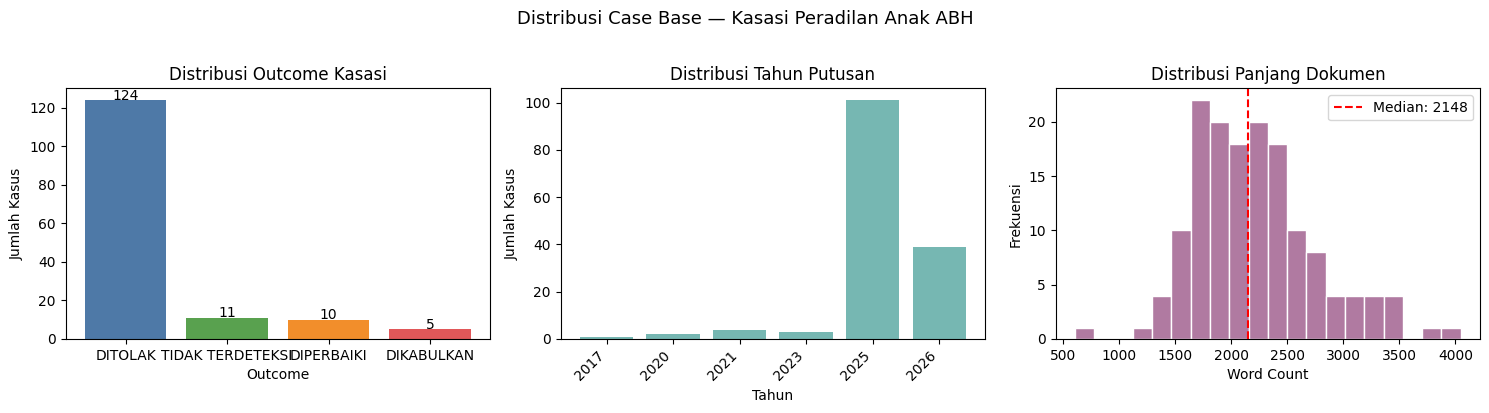

Grafik disimpan -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\distribusi_case_base.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Case Base — Kasasi Peradilan Anak ABH', fontsize=13, y=1.02)

# Plot 1: Outcome kasasi
outcome_counts = df_cb['outcome_kasasi'].value_counts()
colors_out     = ['#4e79a7','#59a14f','#f28e2b','#e15759']
axes[0].bar(outcome_counts.index, outcome_counts.values,
            color=colors_out[:len(outcome_counts)])
axes[0].set_title('Distribusi Outcome Kasasi')
axes[0].set_ylabel('Jumlah Kasus')
axes[0].set_xlabel('Outcome')
for i, (k, v) in enumerate(outcome_counts.items()):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=10)

# Plot 2: Tahun putusan
tahun_counts = df_cb['tahun'].dropna().astype(int).value_counts().sort_index()
axes[1].bar(tahun_counts.index.astype(str), tahun_counts.values, color='#76b7b2')
axes[1].set_title('Distribusi Tahun Putusan')
axes[1].set_ylabel('Jumlah Kasus')
axes[1].set_xlabel('Tahun')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

# Plot 3: Distribusi panjang dokumen (word count)
axes[2].hist(df_cb['word_count'].dropna(), bins=20, color='#b07aa1', edgecolor='white')
axes[2].set_title('Distribusi Panjang Dokumen')
axes[2].set_ylabel('Frekuensi')
axes[2].set_xlabel('Word Count')
axes[2].axvline(df_cb['word_count'].median(), color='red', linestyle='--',
                label=f'Median: {df_cb["word_count"].median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(VIZ_DIR / 'distribusi_case_base.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik disimpan -> {OUT_DIR / "distribusi_case_base.png"}')

## 7 · Quality Assurance — Kelengkapan Field

In [10]:
qa_fields = [
    'nomor_perkara', 'tahun', 'jenis_perkara', 'pasal_didakwakan',
    'terdakwa', 'vonis', 'amar_putusan', 'outcome_kasasi',
    'word_count', 'duduk_perkara', 'memori_kasasi', 'pertimbangan_hukum',
]

print(f"{'Field':<25} {'Terisi':>7} {'Kosong':>7} {'%Terisi':>8}  Catatan")
print('-' * 75)
for col in qa_fields:
    terisi = df_cb[col].astype(str).str.strip().str.len().gt(0).sum()
    kosong = len(df_cb) - terisi
    pct    = terisi / len(df_cb) * 100
    flag   = '  *** perlu review' if pct < 70 else ''
    print(f'{col:<25} {terisi:>7} {kosong:>7} {pct:>7.1f}%{flag}')

print(f'\n[FEATURE ENGINEERING]')
print(f'  word_count — rata-rata : {df_cb["word_count"].mean():.0f} kata')
print(f'  word_count — min/max   : {df_cb["word_count"].min():.0f} / {df_cb["word_count"].max():.0f}')
print(f'  char_count — rata-rata : {df_cb["char_count"].mean():.0f} karakter')

print(f'\n[RINGKASAN]')
print(f'  Total kasus    : {len(df_cb)}')
print(f'  Output JSON    : data/processed/case_base.json')
print(f'  Output CSV     : data/processed/case_base.csv')
print(f'  Distribusi outcome:')
for k, v in df_cb["outcome_kasasi"].value_counts().items():
    print(f'    {k:<20}: {v} ({v/len(df_cb)*100:.1f}%)')
print()
print('Lanjut ke : 03_case_retrieval.ipynb')

Field                      Terisi  Kosong  %Terisi  Catatan
---------------------------------------------------------------------------
nomor_perkara                 150       0   100.0%
tahun                         150       0   100.0%
jenis_perkara                 150       0   100.0%
pasal_didakwakan              150       0   100.0%
terdakwa                      150       0   100.0%
vonis                         148       2    98.7%
amar_putusan                  146       4    97.3%
outcome_kasasi                150       0   100.0%
word_count                    150       0   100.0%
duduk_perkara                 150       0   100.0%
memori_kasasi                 149       1    99.3%
pertimbangan_hukum            150       0   100.0%

[FEATURE ENGINEERING]
  word_count — rata-rata : 2207 kata
  word_count — min/max   : 604 / 4047
  char_count — rata-rata : 14829 karakter

[RINGKASAN]
  Total kasus    : 150
  Output JSON    : data/processed/case_base.json
  Output CSV     : data/pro